--- 步骤 1: 成功读取 600 张图片 ---
--- 步骤 3: PCA 降维完成，特征维度从 2048 降至 19 ---
--- 步骤 4: 正在进行 K-Means 聚类 ---

聚类评估结果:
Adjusted Rand Index (ARI): 1.0000
Normalized Mutual Information (NMI): 1.0000

--- 步骤 5: 正在生成 t-SNE 可视化图表 ---


/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/env_d2l/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/env_d2l/lib/python3.10/s

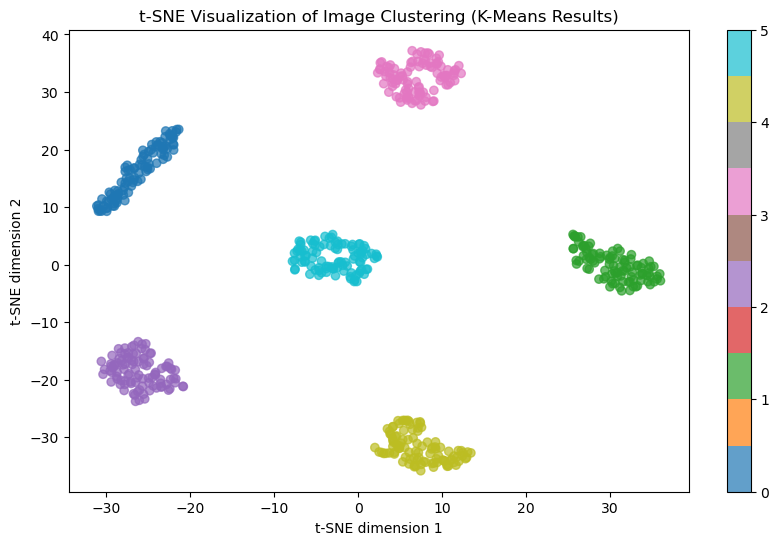

In [2]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE

# ==========================================
# 1. 路径设置与数据准备
# ==========================================
# 使用相对路径，假设代码在 Cluster 文件夹同级的目录下
base_dir = './Cluster'
img_dir = os.path.join(base_dir, 'dataset')
label_file = os.path.join(base_dir, 'cluster_labels.json')

# 定义预处理流 (Standard ImageNet Normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 读取图片文件名并排序，确保与后续标签对应
img_names = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
print(f"--- 步骤 1: 成功读取 {len(img_names)} 张图片 ---")

# 读取 JSON 标签用于评估
with open(label_file, 'r') as f:
    true_labels_dict = json.load(f)

class_names = ['cable', 'tile', 'bottle', 'pill', 'leather', 'transistor']
name_to_idx = {name: i for i, name in enumerate(class_names)}
y_true = np.array([name_to_idx[true_labels_dict[name]] for name in img_names])
# ==========================================
# 2. 特征提取 (使用 ResNet50)
# ==========================================

device = torch.device("cpu")


# # 自动检测设备：如果有 MPS 则使用，否则回退到 CPU
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
#     print("使用 MPS 加速")
# else:
#     device = torch.device("cpu")
#     print("使用 CPU")
# print("--- 正在提取图像特征 (CPU模式，请稍候...) ---")


# 加载预训练模型并去除最后的全连接层
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
extractor = torch.nn.Sequential(*(list(resnet.children())[:-1]))
extractor.to(device)
extractor.eval()

features_list = []
with torch.no_grad():
    for name in img_names:
        img_path = os.path.join(img_dir, name)
        # 加载并预处理图片
        with Image.open(img_path).convert('RGB') as img:
            img_tensor = transform(img).unsqueeze(0).to(device) # 增加 batch 维度
            feat = extractor(img_tensor)
            features_list.append(feat.view(-1).numpy())

all_features = np.array(features_list) # 形状: (600, 2048)


# ==========================================
# 3. 统计降维 (PCA)
# ==========================================
# 降维以保留 95% 的方差，减少 K-Means 计算压力
pca = PCA(n_components=0.95, random_state=42)
features_reduced = pca.fit_transform(all_features)
print(f"--- 步骤 3: PCA 降维完成，特征维度从 2048 降至 {features_reduced.shape[1]} ---")

# ==========================================
# 4. 聚类算法 (K-Means)
# ==========================================
print("--- 步骤 4: 正在进行 K-Means 聚类 ---")
kmeans = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
y_pred = kmeans.fit_predict(features_reduced)

# ==========================================
# 5. 评估与可视化
# ==========================================
# 计算统计指标
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print("\n" + "="*30)
print(f"聚类评估结果:")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
print("="*30 + "\n")

# 可视化 (t-SNE)
print("--- 步骤 5: 正在生成 t-SNE 可视化图表 ---")
tsne = TSNE(n_components=2, init='pca', learning_rate='auto', random_state=42)
tsne_results = tsne.fit_transform(features_reduced)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_pred, cmap='tab10', alpha=0.7)
plt.colorbar(scatter)
plt.title("t-SNE Visualization of Image Clustering (K-Means Results)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.savefig('cluster_tsne.png')
plt.show()